In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from LatticeData import *

# Create F function for lattices of length L

In [2]:
def make_F_mesh(L):
    Fxy = np.ones((L,L), dtype=np.complex_)
    for x, row in enumerate(Fxy):
        for y, val in enumerate(row):
            #print(x,y)
            #print(np.exp(2*np.pi*1j*x/L)+np.exp(2*np.pi*1j*y/L))
            row[y] = np.exp(2*np.pi*1j*x/L)+np.exp(2*np.pi*1j*y/L)
    Fxy = np.round(Fxy, 3)
    return Fxy

def plot_F(Fxy):
    fig, axes = plt.subplots(nrows = 1, ncols = 2)
    axes[0].imshow(Fxy.real)
    axes[0].title.set_text('F_Re')
    axes[1].imshow(Fxy.imag)
    axes[1].title.set_text('F_Im')
    plt.show()

def calc_Xi(Gij):
    Xi = 0.
    for i, gi in enumerate(Gij):
        for j, gij in enumerate(gi):
            Xi += gij
    return Xi

def calc_F(Fxy, Gij):
    sumF = 0.
    Fij = Fxy*G_ij
    for x, row in enumerate(Fij):
        for y, val in enumerate(row):
            sumF += val
    F = 0.5*np.round(sumF,3)
    #for i, gi in enumerate(Gij):
    #    Fi = Fxy[i]
    #    for j, gij in enumerate(gi):
    #        Fi[j] *= gij
    #        F += 0.5*Fi[j]
    return F, Fij

def corr_length(F, Xi, L):
    numerator = np.sqrt(Xi/F-1)
    denominator = 2.*np.sin(np.pi/L)
    return (1.*numerator/denominator)

In [3]:
L = 10
Fxy = make_F_mesh(L)

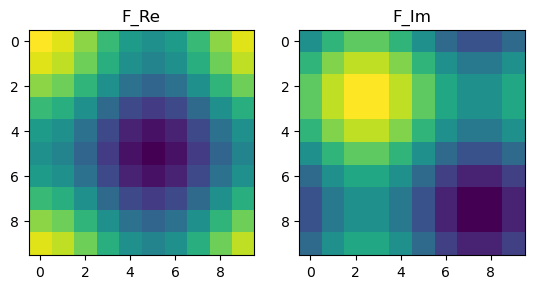

In [4]:
plot_F(Fxy)

In [5]:
sumF = 0.
for x, row in enumerate(Fxy):
    for y, val in enumerate(row):
        sumF += val
print(0.5*np.round(sumF,3))

-0j


# Create analyzer - instantiate class

In [6]:
analysis_data_filepath = "/home/cberger3/nonlinearsigmaCL/Analysis/test/"
source_data_filepath = "/home/cberger3/nonlinearsigmaCL/test/"
analyzer = LatticeData(datadir = analysis_data_filepath, use_full_filepath = True)

In [7]:
analyzer.copy_data_from_directory(source_data_filepath)

## Correlation Function and Correlation Length

NOTE: remember you can't do manual thermalization with G_ij - it's calculated in C++, not in post. 

In [8]:
params = analyzer.all_params()
print(params)

   freq    nMC  ntherm    itheta  beta  length  itheta/pi
0     1  10000       0  0.000000   1.6      10       0.00
0     1  10000       0  0.785398   1.6      10       0.25
0     1  10000       0  1.570796   1.6      10       0.50
0     1  10000       0  2.356194   1.6      10       0.75
0     1  10000       0  3.141593   1.6      10       1.00


In [9]:
itheta = 0.75*np.pi
beta = 1.6
length = 10
nMC = 10000
ntherm = 0
corr_params = {"itheta": itheta, "beta": beta,"length": length,"nMC": nMC, "ntherm": ntherm, "freq":1}

In [10]:
G_ij = analyzer.get_corr_func(suppress_output = False, **corr_params)

freq 1
nMC 10000
ntherm 0
itheta 2.356194
beta 1.6
length 10


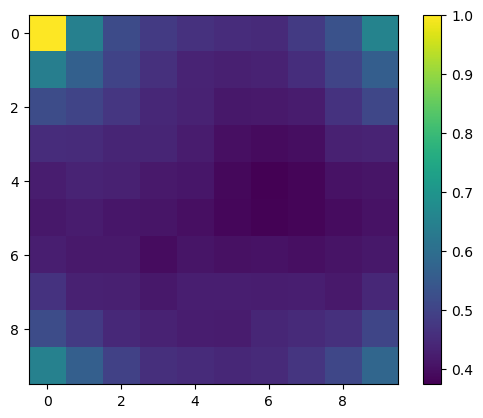

In [11]:
plt.imshow(G_ij, cmap = "viridis", aspect='equal')
plt.colorbar()
plt.show()

In [12]:
Fxy = make_F_mesh(length)
Xi = calc_Xi(G_ij)

In [13]:
F, Fij = calc_F(Fxy, G_ij)

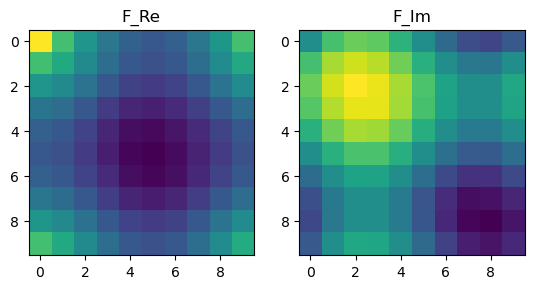

In [14]:
plot_F(Fij)

In [15]:
corr_length = corr_length(F, Xi, length)
mass_gap = 1/corr_length

In [16]:
corr_length

(6.089855413000958-0.06448626227526612j)

In [17]:
mass_gap

(0.16418910058061437+0.0017386195048535679j)

In [ ]:
itheta = 1.0*np.pi
beta = 1.6
length = 20
nMC = 10000
ntherm = 0
corr_params = {"itheta": itheta, "beta": beta,"length": length,"nMC": nMC, "ntherm": ntherm}
G_pi = analyzer.get_corr_func(**corr_params)

In [ ]:
itheta = 0.5*np.pi
beta = 1.6
length = 20
nMC = 10000
ntherm = 0
corr_params = {"itheta": itheta, "beta": beta,"length": length,"nMC": nMC, "ntherm": ntherm}
G_pi2 = analyzer.get_corr_func(**corr_params)

In [ ]:
itheta = 0.25*np.pi
beta = 1.6
length = 20
nMC = 10000
ntherm = 0
corr_params = {"itheta": itheta, "beta": beta,"length": length,"nMC": nMC, "ntherm": ntherm}
G_pi4 = analyzer.get_corr_func(**corr_params)

In [ ]:
itheta = 0.75*np.pi
beta = 1.6
length = 20
nMC = 10000
ntherm = 0
corr_params = {"itheta": itheta, "beta": beta,"length": length,"nMC": nMC, "ntherm": ntherm}
G_3pi4 = analyzer.get_corr_func(**corr_params)

In [ ]:
itheta = 0.0
beta = 1.6
length = 20
nMC = 10000
ntherm = 0
corr_params = {"itheta": itheta, "beta": beta,"length": length,"nMC": nMC, "ntherm": ntherm}
G_0 = analyzer.get_corr_func(**corr_params)

In [ ]:
itheta = 0.125*np.pi
beta = 1.6
length = 20
nMC = 10000
ntherm = 0
corr_params = {"itheta": itheta, "beta": beta,"length": length,"nMC": nMC, "ntherm": ntherm}
G_pi8 = analyzer.get_corr_func(**corr_params)

In [ ]:
Gs = [G_0,G_pi8,G_pi4,G_pi2,G_3pi4,G_pi]
titles = ["itheta = 0","itheta = pi/8","itheta = pi/4","itheta = pi/2", "itheta = 3pi/4","itheta = pi"]
Gmin = np.min(Gs)
Gmax = np.max(Gs)
fig, axs = plt.subplots(2,int(len(Gs)/2), figsize = (10,10))
for n, ax in enumerate(axs.flat):
    im = ax.imshow(Gs[n],vmin = Gmin, vmax = Gmax, cmap = 'inferno')
    ax.set_title(titles[n])
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.subplots_adjust(right=0.8)
fig.colorbar(im, cax=cbar_ax)
plt.show()